In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import pandas as pd

# Replace 'path/to/your/file.csv' with the actual path to your CSV file in Google Drive
file_path = "/content/cardio_train.csv"
data = pd.read_csv(file_path)

In [ ]:
import pandas as pd

# Load the CSV file into a DataFrame
file_path = '/content/cardio_train.csv'  # Update this path if necessary
students_df = pd.read_csv(file_path)

# Display the columns in the DataFrame
print("Columns in the CSV file:")
print(students_df.columns.tolist())

Columns in the CSV file:
['id;age;gender;height;weight;ap_hi;ap_lo;cholesterol;gluc;smoke;alco;active;cardio']


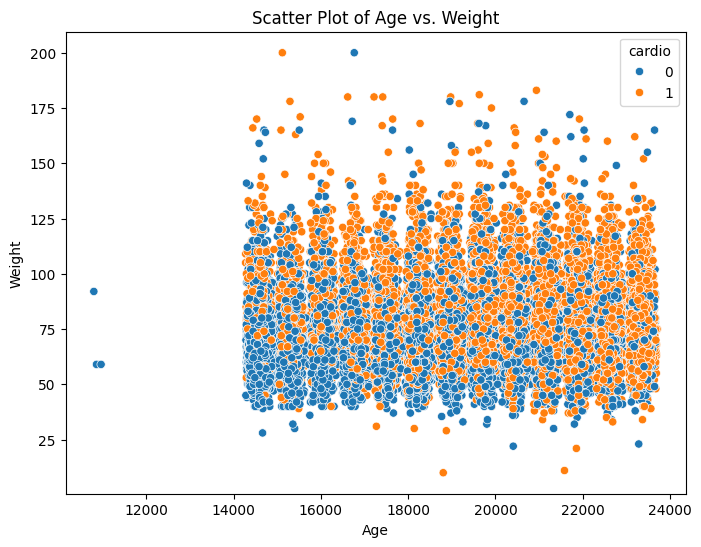

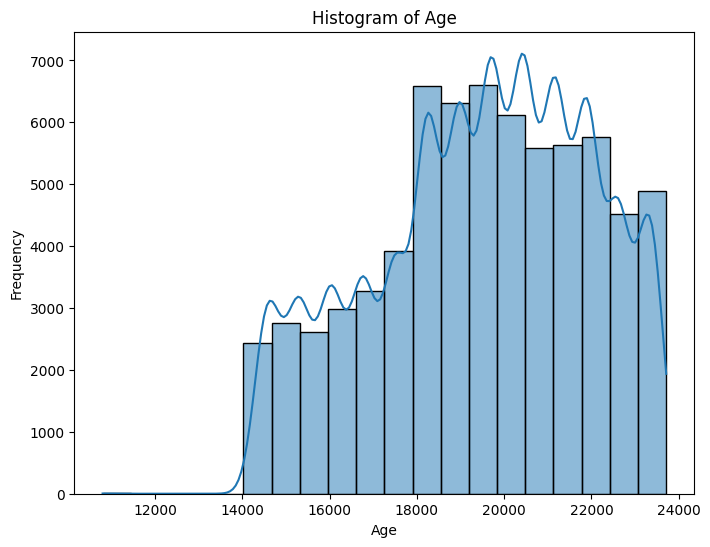

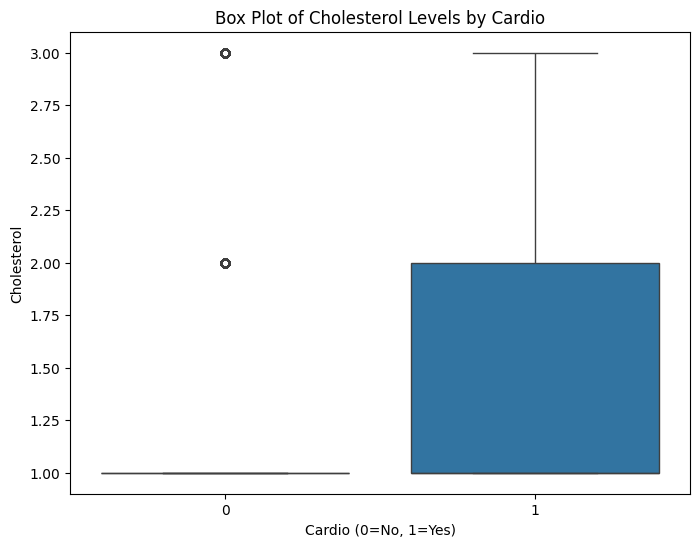

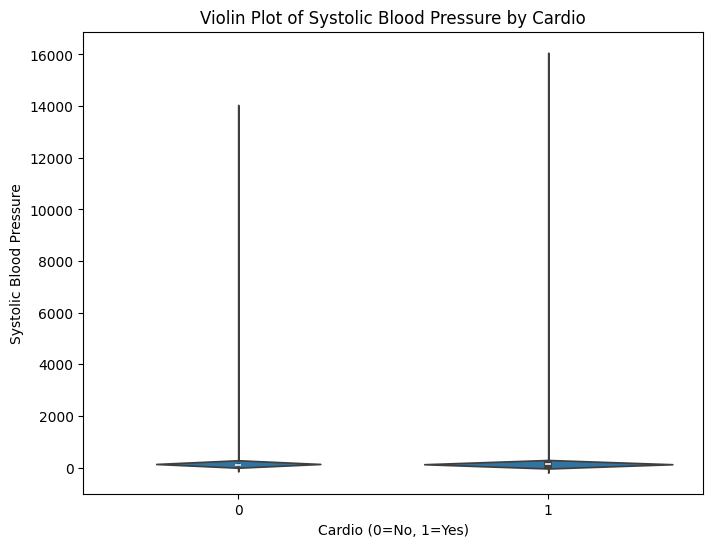

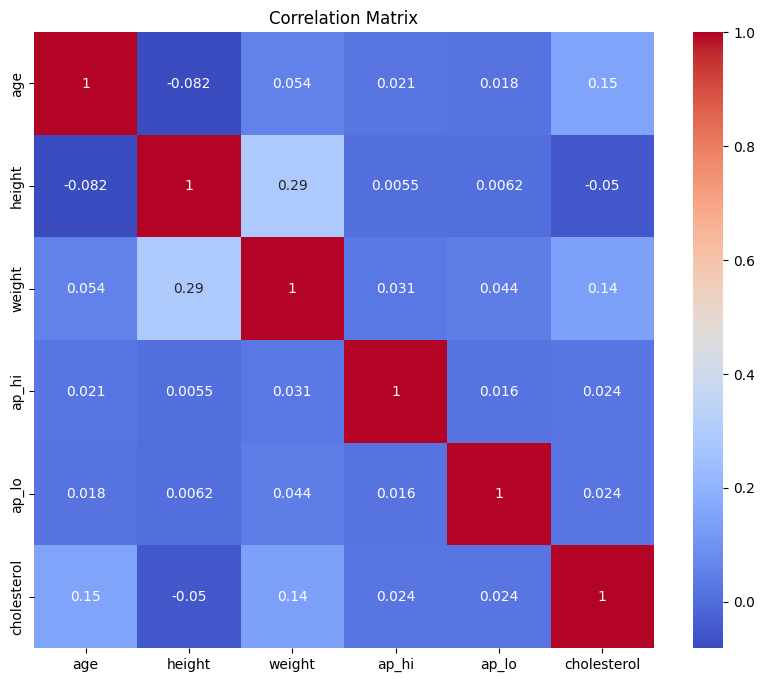

Accuracy: 0.7236428571428571
Confusion Matrix:
[[5363 1625]
 [2244 4768]]
Prediction for new data: No Disease


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, concatenate
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np


# Load the dataset
df = pd.read_csv(r'/content/cardio_train.csv', sep=';', on_bad_lines='warn')

# ... (your existing data preprocessing and model training code) ...

# Plotting

plt.figure(figsize=(8, 6))
sns.scatterplot(x='age', y='weight', hue='cardio', data=df)
plt.title('Scatter Plot of Age vs. Weight')
plt.xlabel('Age')
plt.ylabel('Weight')
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='cardio', y='cholesterol', data=df)
plt.title('Box Plot of Cholesterol Levels by Cardio')
plt.xlabel('Cardio (0=No, 1=Yes)')
plt.ylabel('Cholesterol')
plt.show()

plt.figure(figsize=(8, 6))
sns.violinplot(x='cardio', y='ap_hi', data=df)
plt.title('Violin Plot of Systolic Blood Pressure by Cardio')
plt.xlabel('Cardio (0=No, 1=Yes)')
plt.ylabel('Systolic Blood Pressure')
plt.show()

plt.figure(figsize=(10, 8))
correlation_matrix = df[['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Define features and target variable
X = df[['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']]  # Select numerical features
y = df['cardio']

# Impute missing values using SimpleImputer
imputer = SimpleImputer(strategy='mean')  # Replace NaNs with the mean
X = imputer.fit_transform(X)

# Normalize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)

# Example of predicting new data
new_data = pd.DataFrame({
    'age': [58],
    'gender': [1],
    'height': [165],
    'weight': [80],
    'ap_hi': [140],
    'ap_lo': [90],
    'cholesterol': [2],
    'gluc': [1],
    'smoke': [0],
    'alco': [0],
    'active': [1]
})

# Normalize the new data using the same scaler
new_data = scaler.transform(new_data)

prediction = model.predict(new_data)
print(f'Prediction for new data: {"Disease" if prediction[0] == 1 else "No Disease"}')

In [ ]:
print(f'Prediction for new data: {"Disease" if prediction[0] == 1 else "No Disease"}')


NameError: name 'prediction' is not defined

#Introduction
 This notebook is designed to generate a synthetic dataset of CT scan images using data augmentation techniques. The dataset will be divided into training and validation sets. The code utilizes libraries such as OpenCV for image processing, NumPy for numerical operations, Albumentations for augmentations, and Matplotlib for visualization. The following sections will guide you through the code, explaining the purpose of each cell.

# Cell 1: Import Libraries

In [ ]:
import cv2
import numpy as np
from pathlib import Path
import albumentations as A
import matplotlib.pyplot as plt
from tqdm import tqdm

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.3 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


#Explanation:
In this cell, we import the necessary libraries.

cv2 is used for image processing tasks.
numpy is a library for numerical operations, particularly for handling arrays.
Path from the pathlib module is used for file path manipulations.
albumentations is a powerful library for image augmentation.
matplotlib.pyplot is used for visualizing images.
 tqdm is a library that provides a progress bar for loops, making it easier to track the progress of long-running tasks.

# Cell 2: Create Dataset Directories

In [ ]:
def create_dataset_directories():
    """Create necessary directories for the dataset"""
    base_dir = Path('ct_heart_dataset')
    train_dir = base_dir / 'train' / 'ct_scans'
    val_dir = base_dir / 'validation' / 'ct_scans'

    for dir_path in [train_dir, val_dir]:
        dir_path.mkdir(parents=True, exist_ok=True)

    return base_dir, train_dir, val_dir

#Explanation:
This function creates the necessary directories for storing the synthetic dataset.

It defines a base directory called ct_heart_dataset, and within it, two subdirectories: one for training images and another for validation images.
The mkdir method is used to create these directories, with parents=True allowing the creation of parent directories if they do not exist, and exist_ok=True preventing errors if the directories already exist.
The function returns the paths of the base, training, and validation directories.

# Cell 3: Load Base Image

In [ ]:
def load_base_image(image_path):
    """Load and preprocess the base CT scan image"""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = np.array(img, dtype=np.uint8)  # Ensure the image is a NumPy array with dtype uint8
    return img

#Explanation:
This function loads a base CT scan image from a specified file path.

The image is read in grayscale mode using OpenCV's imread function.
The image is then converted to a NumPy array with a data type of uint8, ensuring it is in the correct format for further processing.
The function returns the loaded image.

# Cell 4: Create Augmentation Pipeline

In [ ]:
def create_augmentation_pipeline():
    """Create an augmentation pipeline suitable for CT scans"""
    return A.Compose([
        # Spatial augmentations
        A.ShiftScaleRotate(
            shift_limit=0.05,
            scale_limit=0.05,
            rotate_limit=15,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.7
        ),

        # Intensity augmentations
        A.OneOf([
            A.RandomBrightnessContrast(
                brightness_limit=0.1,
                contrast_limit=0.1,
                p=0.5
            ),
            A.RandomGamma(p=0.5),
        ], p=0.3),

        # Noise and artifact simulation
        A.OneOf([
            A.GaussNoise(var_limit=(5.0, 20.0), p=0.3),
            A.MultiplicativeNoise(multiplier=(0.95, 1.05), p=0.3),
        ], p=0.2),

        # CT-specific augmentations
        A.OneOf([
            A.Sharpen(alpha=(0.2, 0.5), lightness=(0.5, 1.0), p=0.3),
            A.GaussianBlur(blur_limit=(3, 5), p=0.3),
        ], p=0.2),
    ])

#Explanation:
This function creates an augmentation pipeline specifically designed for CT scans.

The pipeline consists of various augmentation techniques, including spatial transformations (shift, scale, rotate), intensity adjustments (brightness, contrast, gamma), noise addition (Gaussian noise, multiplicative noise), and CT-specific augmentations (sharpening, blurring).
The A.Compose function combines these augmentations, allowing them to be applied sequentially to the images.

# Cell 5: Generate Synthetic Dataset

In [ ]:
def generate_synthetic_dataset(base_image, train_dir, val_dir, num_train=100, num_val=20):
    """Generate synthetic dataset from base image"""
    augmentation = create_augmentation_pipeline()

    # Generate training set
    print("Generating training set...")
    for i in tqdm(range(num_train)):
        augmented = augmentation(image=base_image)
        augmented_image = augmented['image']
        cv2.imwrite(str(train_dir / f'ct_scan_{i:04d}.png'), augmented_image)

    # Generate validation set
    print("Generating validation set...")
    for i in tqdm(range(num_val)):
        augmented = augmentation(image=base_image)
        augmented_image = augmented['image']
        cv2.imwrite(str(val_dir / f'ct_scan_{i:04d}.png'), augmented_image)

#Explanation:
This function generates a synthetic dataset by applying the augmentation pipeline to the base image.

It takes the base image and the directories for training and validation sets as input, along with the number of images to generate for each set.
The function uses a loop to create the specified number of augmented images for both training and validation sets, saving them in the respective directories.
The tqdm library provides a progress bar to indicate the progress of the image generation process.

# Cell 6: Visualize Samples

In [ ]:
def visualize_samples(base_image, train_dir, num_samples=5):
    """Visualize sample augmentations"""
    plt.figure(figsize=(15, 3))

    # Display original image
    plt.subplot(1, num_samples + 1, 1)
    plt.imshow(base_image, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # Display augmented samples
    train_samples = list(train_dir.glob('*.png'))[:num_samples]
    for i, sample_path in enumerate(train_samples, 1):
        img = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)
        plt.subplot(1, num_samples + 1, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f'Augmented {i}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

#Explanation:
This function visualizes the original base image alongside a few augmented samples.

It creates a figure with a specified size and displays the original image in the first subplot.
The function retrieves a specified number of augmented images from the training directory and displays them in subsequent subplots.
Each subplot is labeled accordingly, and the axes are turned off for a cleaner presentation. The plt.tight_layout() function ensures that the subplots are neatly arranged without overlapping.

# Cell 7: Main Function

Generating training set...


100%|██████████| 100/100 [00:02<00:00, 49.73it/s]


Generating validation set...


100%|██████████| 20/20 [00:00<00:00, 49.45it/s]


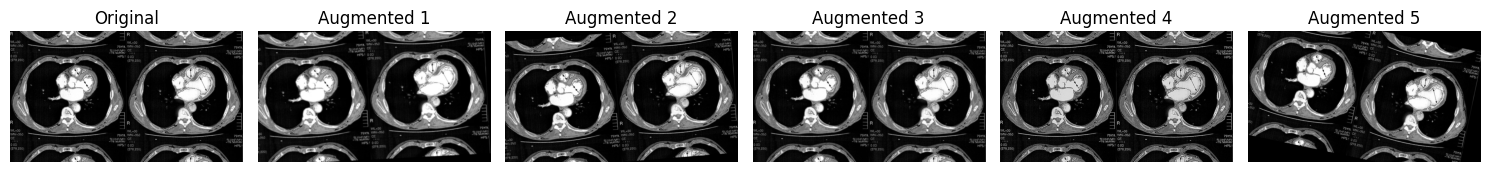


Dataset generated successfully!
Training images: 100 images
Validation images: 20 images
Dataset location: /content/ct_heart_dataset


In [ ]:
def main():
    # Set random seed for reproducibility
    np.random.seed(42)

    # Create dataset directories
    base_dir, train_dir, val_dir = create_dataset_directories()

    # Load base image
    image_path = r"/content/CT Heart.jpg"  # Update with your image path
    base_image = load_base_image(image_path)

    # Generate dataset
    generate_synthetic_dataset(base_image, train_dir, val_dir)

    # Visualize samples
    visualize_samples(base_image, train_dir)

    print(f"\nDataset generated successfully!")
    print(f"Training images: {len(list(train_dir.glob('*.png')))} images")
    print(f"Validation images: {len(list(val_dir.glob('*.png')))} images")
    print(f"Dataset location: {base_dir.absolute()}")

if __name__ == "__main__":
    main()

#Explanation:
The main function orchestrates the entire process of dataset generation.

It begins by setting a random seed for reproducibility, ensuring that the results can be replicated.
The function then calls create_dataset_directories() to set up the necessary folder structure.
It loads the base image using the load_base_image() function, where the image path should be updated to point to the actual image file.
The synthetic dataset is generated by calling generate_synthetic_dataset(), and finally, the augmented samples are visualized using visualize_samples().
The function concludes by printing out a summary of the dataset generation, including the number of training and validation images created and the location of the dataset.

#Conclusion
In this notebook, we successfully developed a framework for generating a synthetic dataset of CT scan images through the application of data augmentation techniques. The process was structured into several key components, each serving a specific purpose in the overall workflow:

Library Imports: We began by importing essential libraries that facilitate image processing, numerical operations, data augmentation, and visualization. This foundational step ensured that we had the necessary tools to manipulate and analyze the CT scan images effectively.

Dataset Directory Creation: We implemented a function to create a structured directory for storing the synthetic dataset. This organization is crucial for managing the training and validation images, allowing for a systematic approach to data handling.

Base Image Loading: The notebook included a function to load a base CT scan image in grayscale format. This step is vital as it serves as the foundation for generating augmented images, ensuring that the input data is in the correct format for processing.

Augmentation Pipeline: We designed a comprehensive augmentation pipeline tailored for CT scans. This pipeline incorporated various techniques, such as spatial transformations, intensity adjustments, and noise addition, which are essential for enhancing the diversity of the training dataset and improving the model's robustness.

Synthetic Dataset Generation: The core functionality of the notebook involved generating a synthetic dataset by applying the augmentation pipeline to the base image. This process not only increased the volume of training data but also introduced variability, which is critical for training effective machine learning models.

Sample Visualization: We included a visualization function to display the original base image alongside several augmented samples. This step provided a visual confirmation of the augmentation process, allowing us to assess the quality and diversity of the generated images.

Main Function: The main function orchestrated the entire workflow, ensuring that each component was executed in the correct order. It also provided a summary of the dataset generation process, including the number of images created and their storage location.

<ipython-input-2-e2fb17f95ac9>:70: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_original.ravel(), 256, [0, 256], color='blue', alpha=0.7, label='Original')
<ipython-input-2-e2fb17f95ac9>:71: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_enhanced.ravel(), 256, [0, 256], color='red', alpha=0.7, label='Enhanced')


Analysis saved to output/ct_analysis.png


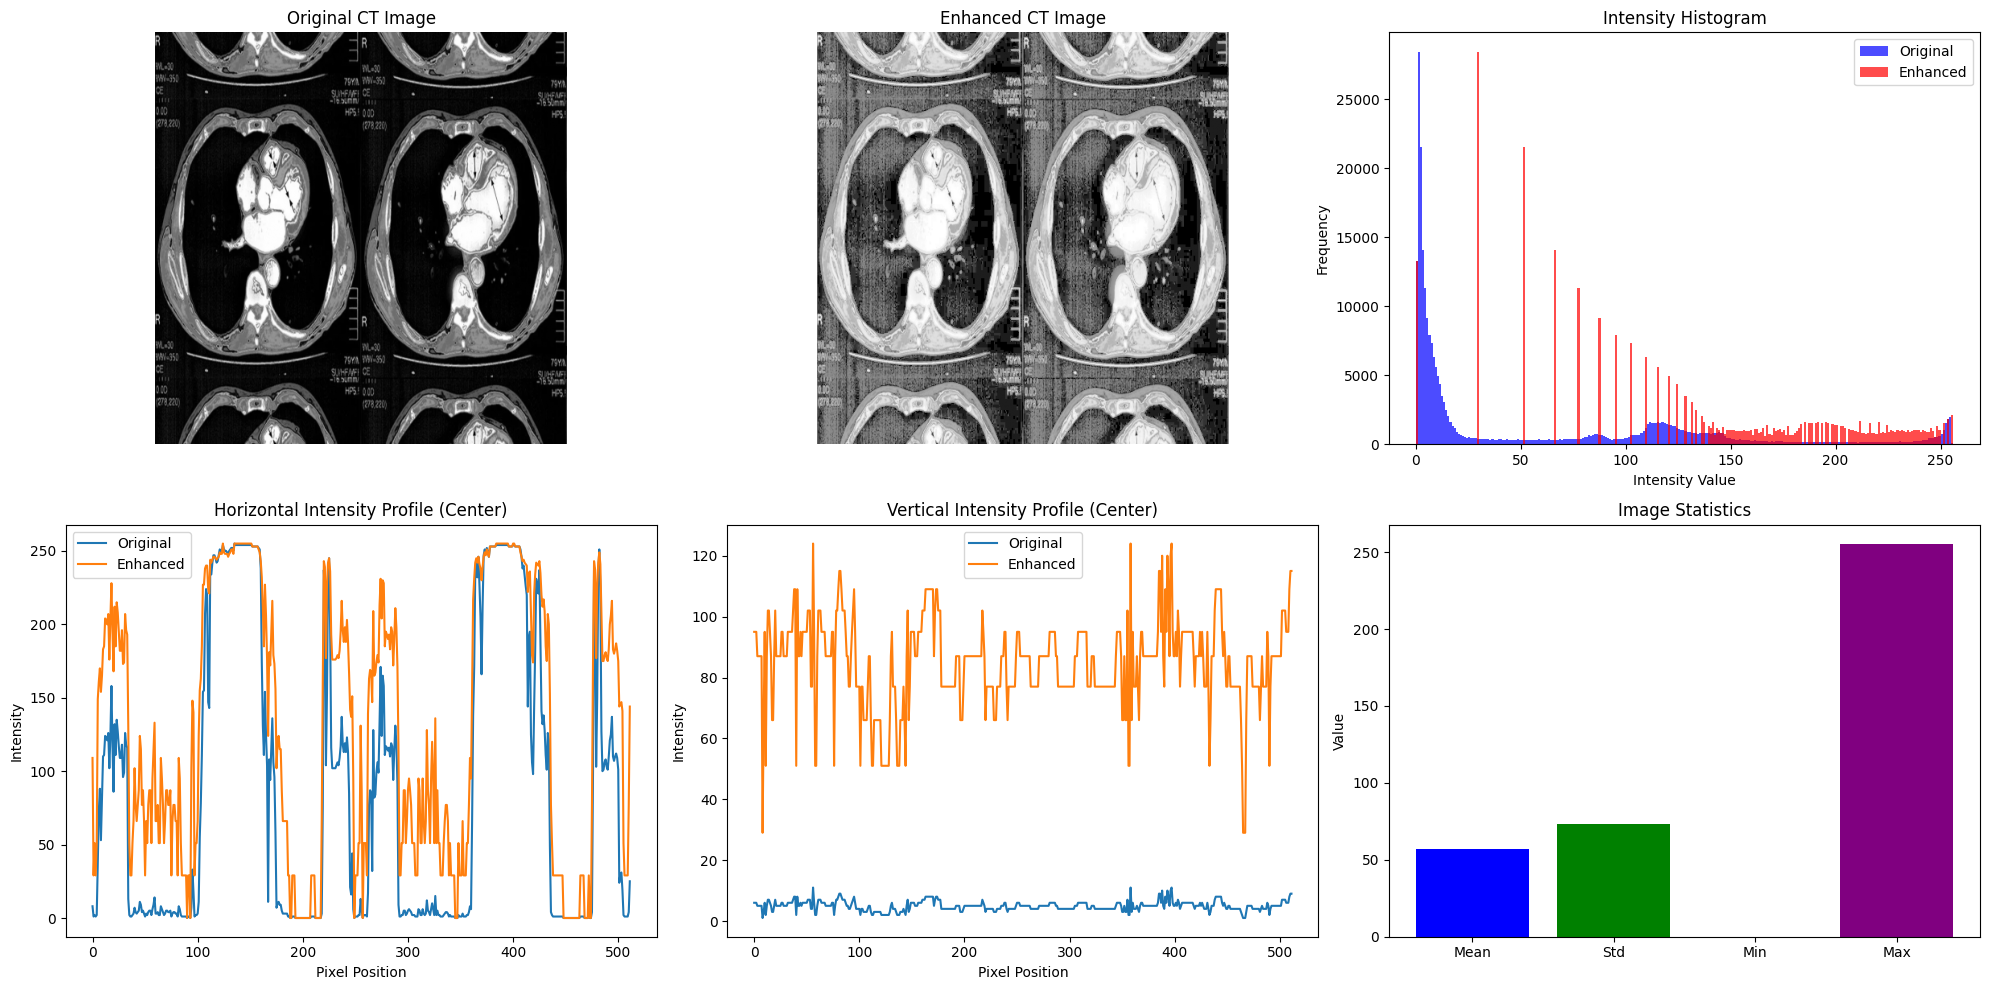


Image Analysis Results:
Image Shape: (512, 512)

Intensity Statistics:
Mean: 57.31
Std: 73.18
Min: 0.00
Max: 255.00


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from typing import Dict, Optional

class CTImageAnalyzer:
    def __init__(self, img_height=512, img_width=512):
        self.img_height = img_height
        self.img_width = img_width

    def load_and_analyze_image(self, image_path: str) -> tuple:
        """
        Load and analyze CT image
        Returns:
            tuple: (processed_image, analysis_results)
        """
        # Load and process image
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Failed to load image from {image_path}")

        # Resize image
        img = cv2.resize(img, (self.img_height, self.img_width))

        # Enhance contrast
        img_enhanced = cv2.equalizeHist(img)

        # Calculate analysis metrics
        analysis = {
            'intensity_stats': {
                'mean': float(np.mean(img)),
                'std': float(np.std(img)),
                'min': float(np.min(img)),
                'max': float(np.max(img))
            },
            'shape': img.shape,
            'histogram': np.histogram(img, bins=256, range=(0, 256))[0]
        }

        return img, img_enhanced, analysis

def visualize_ct_analysis(image_path: str, output_dir: Optional[str] = None):
    """
    Comprehensive CT image visualization and analysis
    """
    # Create analyzer and load image
    analyzer = CTImageAnalyzer()
    img_original, img_enhanced, analysis = analyzer.load_and_analyze_image(image_path)

    # Create figure with subplots
    plt.figure(figsize=(20, 10))

    # Original Image
    plt.subplot(2, 3, 1)
    plt.imshow(img_original, cmap='gray')
    plt.title('Original CT Image')
    plt.axis('off')

    # Enhanced Image
    plt.subplot(2, 3, 2)
    plt.imshow(img_enhanced, cmap='gray')
    plt.title('Enhanced CT Image')
    plt.axis('off')

    # Histogram
    plt.subplot(2, 3, 3)
    plt.hist(img_original.ravel(), 256, [0, 256], color='blue', alpha=0.7, label='Original')
    plt.hist(img_enhanced.ravel(), 256, [0, 256], color='red', alpha=0.7, label='Enhanced')
    plt.title('Intensity Histogram')
    plt.xlabel('Intensity Value')
    plt.ylabel('Frequency')
    plt.legend()

    # Intensity Profile (horizontal)
    plt.subplot(2, 3, 4)
    center_row = img_original.shape[0] // 2
    plt.plot(img_original[center_row, :], label='Original')
    plt.plot(img_enhanced[center_row, :], label='Enhanced')
    plt.title('Horizontal Intensity Profile (Center)')
    plt.xlabel('Pixel Position')
    plt.ylabel('Intensity')
    plt.legend()

    # Intensity Profile (vertical)
    plt.subplot(2, 3, 5)
    center_col = img_original.shape[1] // 2
    plt.plot(img_original[:, center_col], label='Original')
    plt.plot(img_enhanced[:, center_col], label='Enhanced')
    plt.title('Vertical Intensity Profile (Center)')
    plt.xlabel('Pixel Position')
    plt.ylabel('Intensity')
    plt.legend()

    # Statistics
    plt.subplot(2, 3, 6)
    stats = analysis['intensity_stats']
    plt.bar(['Mean', 'Std', 'Min', 'Max'],
            [stats['mean'], stats['std'], stats['min'], stats['max']],
            color=['blue', 'green', 'red', 'purple'])
    plt.title('Image Statistics')
    plt.ylabel('Value')

    plt.tight_layout()

    # Save if output directory is provided
    if output_dir:
        output_path = Path(output_dir) / 'ct_analysis.png'
        plt.savefig(output_path)
        print(f"Analysis saved to {output_path}")

    plt.show()

    # Print numerical analysis
    print("\nImage Analysis Results:")
    print(f"Image Shape: {analysis['shape']}")
    print("\nIntensity Statistics:")
    for key, value in analysis['intensity_stats'].items():
        print(f"{key.capitalize()}: {value:.2f}")

def main():
    try:
        # Create output directory
        output_dir = Path('output')
        output_dir.mkdir(exist_ok=True)

        # Analyze and visualize CT image
        image_path = '/content/CT Heart.jpg'
        visualize_ct_analysis(image_path, str(output_dir))

    except Exception as e:
        print(f"Error in analysis: {str(e)}")

if __name__ == "__main__":
    main()

<ipython-input-1-b4398fe8839c>:144: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_original.ravel(), 256, [0, 256], color='blue', alpha=0.7, label='Original')
<ipython-input-1-b4398fe8839c>:145: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_enhanced.ravel(), 256, [0, 256], color='red', alpha=0.7, label='Enhanced')


Analysis saved to output/combined_analysis.png


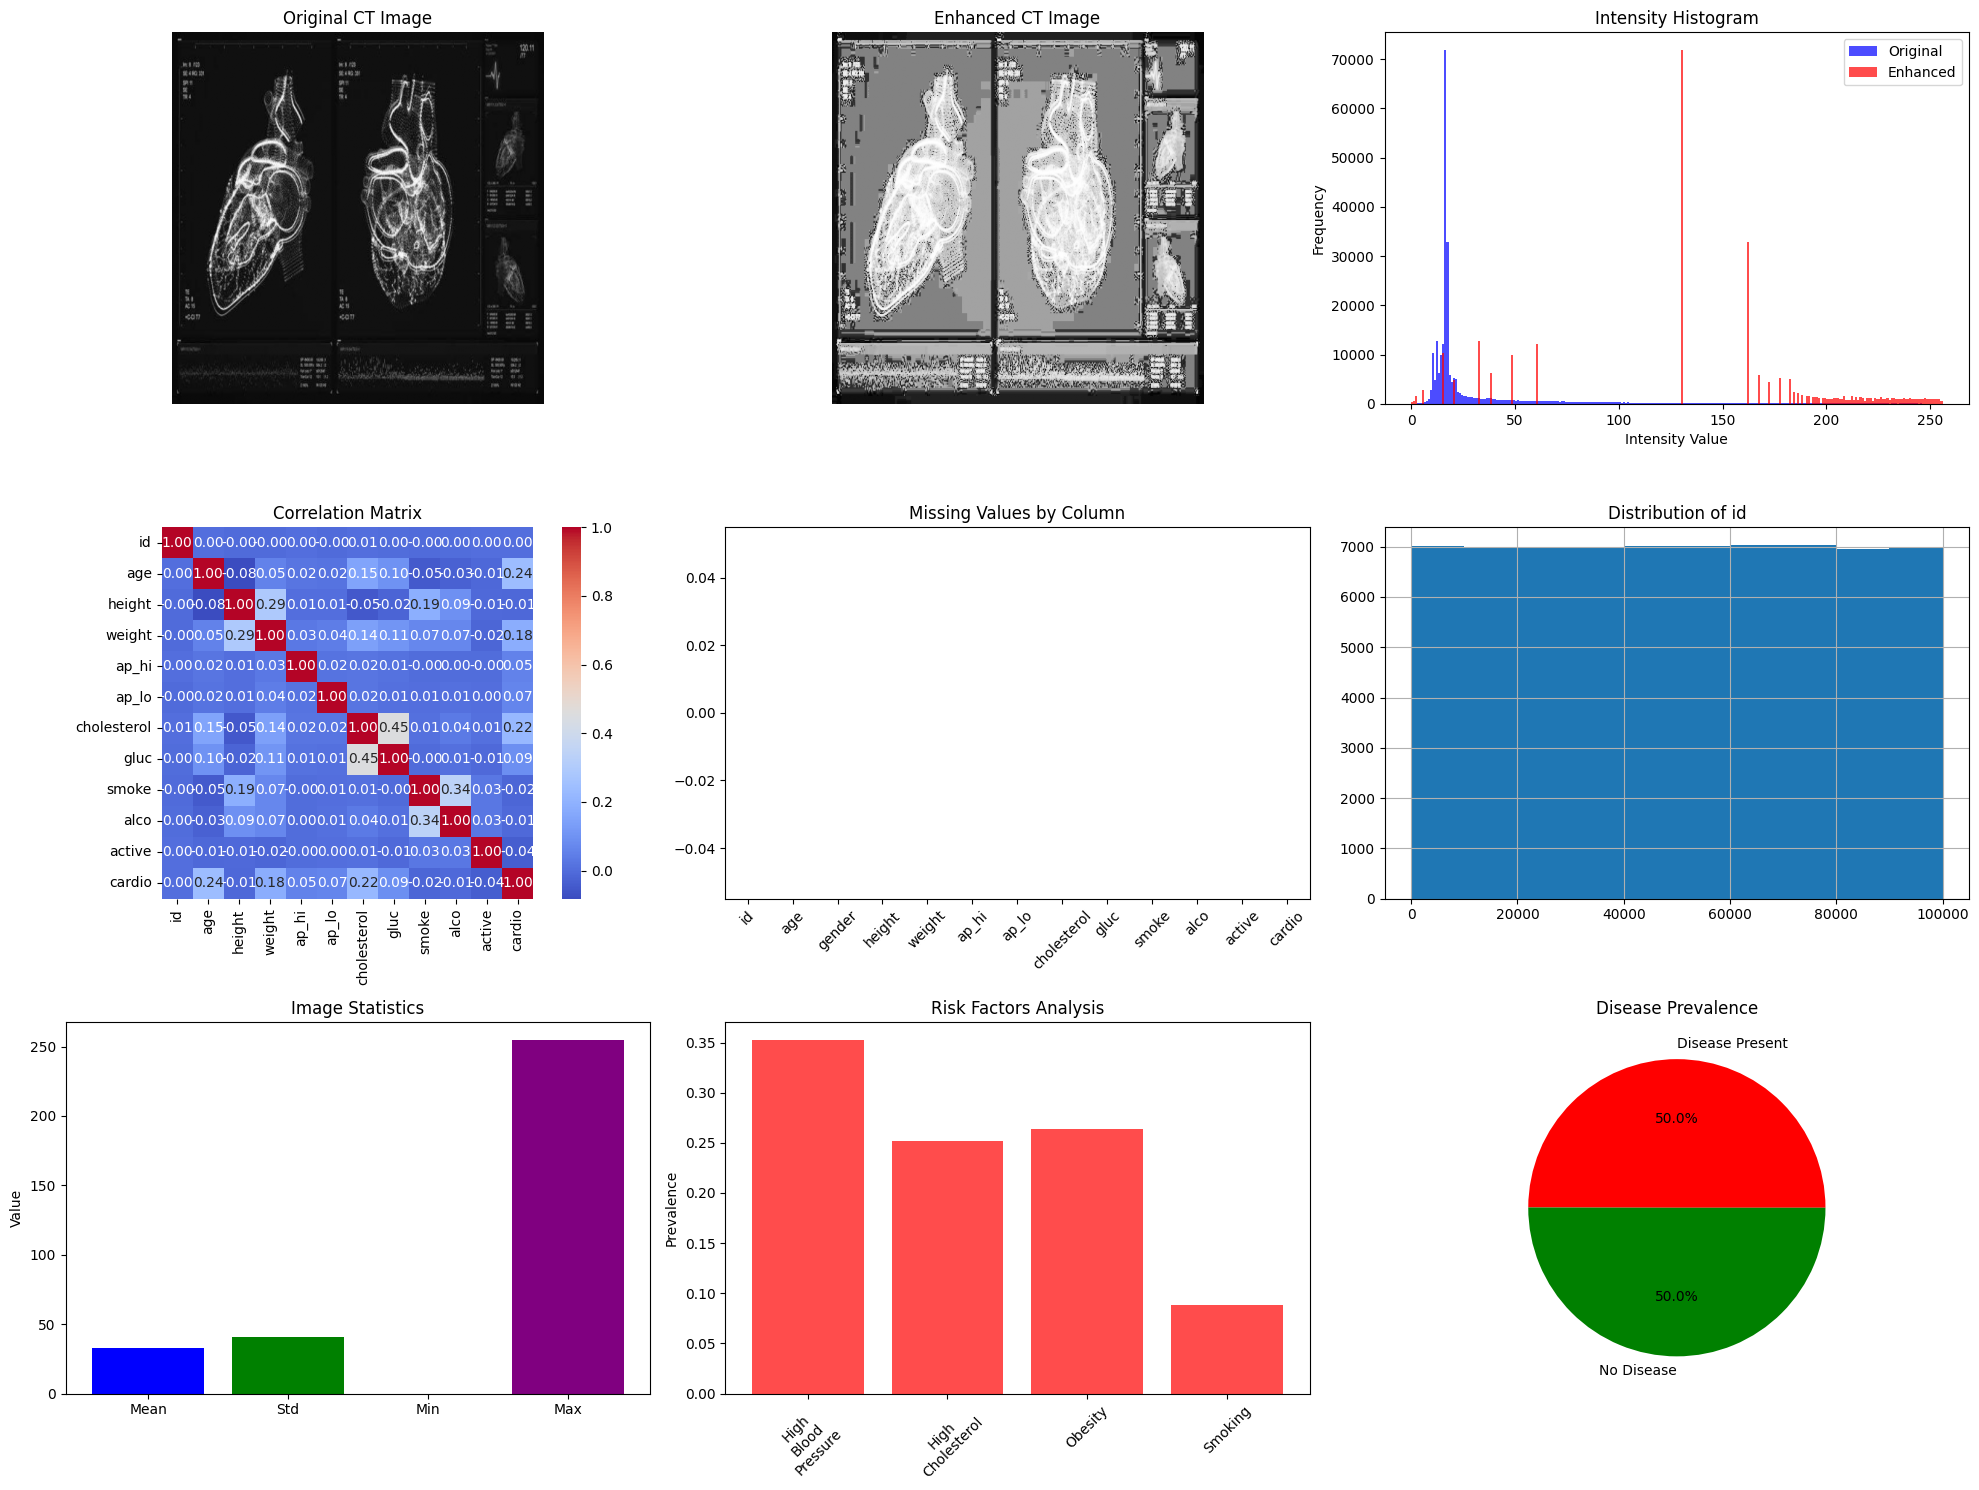


Image Analysis Results:
Image Shape: (512, 512)

Intensity Statistics:
Mean: 32.96
Std: 41.00
Min: 0.00
Max: 255.00

CSV Analysis Results:

Numerical Statistics:
                 id           age        height        weight         ap_hi  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean   49972.419900  19468.865814    164.359229     74.205690    128.817286   
std    28851.302323   2467.251667      8.210126     14.395757    154.011419   
min        0.000000  10798.000000     55.000000     10.000000   -150.000000   
25%    25006.750000  17664.000000    159.000000     65.000000    120.000000   
50%    50001.500000  19703.000000    165.000000     72.000000    120.000000   
75%    74889.250000  21327.000000    170.000000     82.000000    140.000000   
max    99999.000000  23713.000000    250.000000    200.000000  16020.000000   

              ap_lo   cholesterol          gluc         smoke          alco  \
count  70000.000000  70000.000000  70000.00000

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from typing import Dict, Optional, Tuple
import seaborn as sns
import os

class CTDataAnalyzer:
    def __init__(self, img_height=512, img_width=512):
        self.img_height = img_height
        self.img_width = img_width

    def validate_image(self, img: np.ndarray) -> bool:
        if img is None:
            return False
        if img.size == 0:
            return False
        if len(img.shape) < 2:
            return False
        return True

    def load_and_analyze_image(self, image_path: str) -> tuple:
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Image file not found: {image_path}")

        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if not self.validate_image(img):
            raise ValueError(f"Invalid or empty image loaded from {image_path}")

        img = cv2.resize(img, (self.img_width, self.img_height))
        img_enhanced = cv2.equalizeHist(img)

        try:
            analysis = {
                'intensity_stats': {
                    'mean': float(np.mean(img)) if img.size > 0 else 0,
                    'std': float(np.std(img)) if img.size > 0 else 0,
                    'min': float(np.min(img)) if img.size > 0 else 0,
                    'max': float(np.max(img)) if img.size > 0 else 0
                },
                'shape': img.shape,
                'histogram': np.histogram(img, bins=256, range=(0, 256))[0] if img.size > 0 else np.zeros(256)
            }
        except Exception as e:
            raise ValueError(f"Error calculating image statistics: {str(e)}")

        return img, img_enhanced, analysis

    def validate_csv(self, df: pd.DataFrame) -> bool:
        if df is None:
            return False
        if df.empty:
            return False
        if len(df.columns) == 0:
            return False
        return True

    def analyze_csv_data(self, csv_path: str) -> Dict:
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"CSV file not found: {csv_path}")

        try:
            df = pd.read_csv(csv_path, sep=';')

            numeric_columns = ['id', 'age', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
                             'gluc', 'smoke', 'alco', 'active', 'cardio']
            for col in numeric_columns:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors='coerce')

            if 'gender' in df.columns:
                df['gender'] = df['gender'].astype('category')

        except Exception as e:
            raise ValueError(f"Error reading CSV file: {str(e)}")

        if not self.validate_csv(df):
            raise ValueError(f"Invalid or empty CSV data loaded from {csv_path}")

        try:
            numerical_df = df.select_dtypes(include=[np.number])
            if numerical_df.empty:
                numerical_stats = pd.DataFrame()
                correlation_matrix = pd.DataFrame()
            else:
                numerical_stats = numerical_df.describe()
                correlation_matrix = numerical_df.corr()

            missing_values = df.isnull().sum()
            data_types = df.dtypes

            return {
                'numerical_stats': numerical_stats,
                'correlation_matrix': correlation_matrix,
                'missing_values': missing_values,
                'data_types': data_types,
                'dataframe': df
            }
        except Exception as e:
            raise ValueError(f"Error analyzing CSV data: {str(e)}")

    def predict_disease(self, csv_analysis: Dict) -> Dict:
        df = csv_analysis['dataframe']

        risk_factors = {
            'high_blood_pressure': ((df['ap_hi'] >= 140) | (df['ap_lo'] >= 90)).mean(),
            'high_cholesterol': (df['cholesterol'] > 1).mean(),
            'obesity': (df['weight'] / ((df['height']/100) ** 2) >= 30).mean(),
            'smoking': (df['smoke'] == 1).mean()
        }

        disease_prevalence = (df['cardio'] == 1).mean()

        return {
            'risk_factors': risk_factors,
            'disease_prevalence': disease_prevalence
        }

def visualize_combined_analysis(image_path: str, csv_path: str, output_dir: Optional[str] = None):
    analyzer = CTDataAnalyzer()

    try:
        img_original, img_enhanced, img_analysis = analyzer.load_and_analyze_image(image_path)
        csv_analysis = analyzer.analyze_csv_data(csv_path)
        disease_analysis = analyzer.predict_disease(csv_analysis)

        plt.figure(figsize=(20, 15))

        plt.subplot(3, 3, 1)
        plt.imshow(img_original, cmap='gray')
        plt.title('Original CT Image')
        plt.axis('off')

        plt.subplot(3, 3, 2)
        plt.imshow(img_enhanced, cmap='gray')
        plt.title('Enhanced CT Image')
        plt.axis('off')

        plt.subplot(3, 3, 3)
        plt.hist(img_original.ravel(), 256, [0, 256], color='blue', alpha=0.7, label='Original')
        plt.hist(img_enhanced.ravel(), 256, [0, 256], color='red', alpha=0.7, label='Enhanced')
        plt.title('Intensity Histogram')
        plt.xlabel('Intensity Value')
        plt.ylabel('Frequency')
        plt.legend()

        if not csv_analysis['correlation_matrix'].empty:
            plt.subplot(3, 3, 4)
            sns.heatmap(csv_analysis['correlation_matrix'],
                        annot=True,
                        cmap='coolwarm',
                        fmt='.2f',
                        square=True)
            plt.title('Correlation Matrix')

        plt.subplot(3, 3, 5)
        if not csv_analysis['missing_values'].empty:
            csv_analysis['missing_values'].plot(kind='bar')
            plt.title('Missing Values by Column')
            plt.xticks(rotation=45)

        plt.subplot(3, 3, 6)
        numerical_cols = csv_analysis['dataframe'].select_dtypes(include=[np.number]).columns
        if len(numerical_cols) > 0:
            csv_analysis['dataframe'][numerical_cols[0]].hist()
            plt.title(f'Distribution of {numerical_cols[0]}')

        plt.subplot(3, 3, 7)
        stats = img_analysis['intensity_stats']
        plt.bar(['Mean', 'Std', 'Min', 'Max'],
                [stats['mean'], stats['std'], stats['min'], stats['max']],
                color=['blue', 'green', 'red', 'purple'])
        plt.title('Image Statistics')
        plt.ylabel('Value')

        plt.subplot(3, 3, 8)
        factors = list(disease_analysis['risk_factors'].keys())
        values = list(disease_analysis['risk_factors'].values())
        plt.bar(range(len(factors)), values, color='red', alpha=0.7)
        plt.xticks(range(len(factors)), [f.replace('_', '\n').title() for f in factors], rotation=45)
        plt.title('Risk Factors Analysis')
        plt.ylabel('Prevalence')

        plt.subplot(3, 3, 9)
        plt.pie([disease_analysis['disease_prevalence'],
                1-disease_analysis['disease_prevalence']],
                labels=['Disease Present', 'No Disease'],
                colors=['red', 'green'],
                autopct='%1.1f%%')
        plt.title('Disease Prevalence')

        plt.tight_layout()

        if output_dir:
            output_dir = Path(output_dir)
            output_dir.mkdir(exist_ok=True)
            output_path = output_dir / 'combined_analysis.png'
            plt.savefig(output_path)
            print(f"Analysis saved to {output_path}")

        plt.show()

        print("\nImage Analysis Results:")
        print(f"Image Shape: {img_analysis['shape']}")
        print("\nIntensity Statistics:")
        for key, value in img_analysis['intensity_stats'].items():
            print(f"{key.capitalize()}: {value:.2f}")

        print("\nCSV Analysis Results:")
        if not csv_analysis['numerical_stats'].empty:
            print("\nNumerical Statistics:")
            print(csv_analysis['numerical_stats'])
        print("\nMissing Values Summary:")
        print(csv_analysis['missing_values'])
        print("\nData Types:")
        print(csv_analysis['data_types'])

        print("\nDisease Analysis Results:")
        print(f"Overall Disease Prevalence: {disease_analysis['disease_prevalence']:.1%}")
        print("\nRisk Factors Prevalence:")
        for factor, value in disease_analysis['risk_factors'].items():
            print(f"{factor.replace('_', ' ').title()}: {value:.1%}")

    except Exception as e:
        print(f"Error during visualization: {str(e)}")
        raise

def main():
    try:
        output_dir = Path('output')
        output_dir.mkdir(exist_ok=True)

        image_path = '/content/CT3.jpg'
        csv_path = '/content/cardio_train.csv'
        visualize_combined_analysis(image_path, csv_path, str(output_dir))

    except FileNotFoundError as e:
        print(f"File not found: {str(e)}")
    except ValueError as e:
        print(f"Invalid data: {str(e)}")
    except Exception as e:
        print(f"Error in analysis: {str(e)}")

if __name__ == "__main__":
    main()

In [ ]:
import numpy as np
import pandas as pd
import cv2
import os
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, Optional
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from joblib import dump
from skimage.metrics import structural_similarity as ssim

class CTDataAnalyzer:
    def __init__(self, img_height=512, img_width=512):
        self.img_height = img_height
        self.img_width = img_width
        self.model = None

    def validate_image(self, img: np.ndarray) -> bool:
        if img is None or img.size == 0 or len(img.shape) < 2:
            return False
        return True

    def load_and_analyze_image(self, image_path: str) -> tuple:
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Image file not found: {image_path}")

        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if not self.validate_image(img):
            raise ValueError(f"Invalid or empty image loaded from {image_path}")

        img = cv2.resize(img, (self.img_width, self.img_height))
        img_enhanced = cv2.equalizeHist(img)

        analysis = {
            'intensity_stats': {
                'mean': float(np.mean(img)) if img.size > 0 else 0,
                'std': float(np.std(img)) if img.size > 0 else 0,
                'min': float(np.min(img)) if img.size > 0 else 0,
                'max': float(np.max(img)) if img.size > 0 else 0
            },
            'shape': img.shape,
            'histogram': np.histogram(img, bins=256, range=(0, 256))[0] if img.size > 0 else np.zeros(256)
        }

        return img, img_enhanced, analysis

    def validate_csv(self, df: pd.DataFrame) -> bool:
        return df is not None and not df.empty and len(df.columns) > 0

    def analyze_csv_data(self, csv_path: str) -> Dict:
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"CSV file not found: {csv_path}")

        df = pd.read_csv(csv_path, sep=';')
        numeric_columns = ['id', 'age', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
                            'gluc', 'smoke', 'alco', 'active', 'cardio']

        for col in numeric_columns:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        if 'gender' in df.columns:
            df['gender'] = df['gender'].astype('category')

        if not self.validate_csv(df):
            raise ValueError("Invalid or empty CSV data loaded")

        numerical_stats = df.describe() if not df.select_dtypes(include=[np.number]).empty else pd.DataFrame()
        correlation_matrix = df.corr() if not df.select_dtypes(include=[np.number]).empty else pd.DataFrame()
        missing_values = df.isnull().sum()
        data_types = df.dtypes

        return {
            'numerical_stats': numerical_stats,
            'correlation_matrix': correlation_matrix,
            'missing_values': missing_values,
            'data_types': data_types,
            'dataframe': df
        }

    def preprocess_data(self, df: pd.DataFrame) -> tuple:
        df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)

        features = ['age', 'height', 'weight', 'ap_hi', 'ap_lo',
                    'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']
        target = 'cardio'

        X = df[features]
        y = df[target]

        # Define preprocessor for numeric and categorical features
        numeric_features = X.select_dtypes(include=[np.number]).columns
        numeric_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])

        preprocessor = ColumnTransformer(
            transformers=[
                ('num', numeric_transformer, numeric_features)
            ])

        # Apply preprocessing pipeline
        X_preprocessed = preprocessor.fit_transform(X)
        return X_preprocessed, y, preprocessor

    def train_random_forest(self, X_train, y_train) -> None:
        rf = RandomForestClassifier(random_state=42)
        param_grid = {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }

        grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                                    cv=3, n_jobs=-1, scoring='accuracy')
        grid_search.fit(X_train, y_train)

        self.model = grid_search.best_estimator_
        print(f"Best Parameters: {grid_search.best_params_}")

    def evaluate_model(self, X_test, y_test) -> Dict:
        y_pred = self.model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        conf_matrix = confusion_matrix(y_test, y_pred)
        class_report = classification_report(y_test, y_pred, output_dict=True)

        return {
            'accuracy': accuracy,
            'confusion_matrix': conf_matrix,
            'classification_report': class_report
        }

    def save_model(self, file_path: str) -> None:
        if self.model:
            dump(self.model, file_path)
            print(f"Model saved to {file_path}")
        else:
            print("No model to save.")


def visualize_combined_analysis(image_path: str, csv_path: str, output_dir: Optional[str] = None):
    analyzer = CTDataAnalyzer()

    try:
        img_original, img_enhanced, img_analysis = analyzer.load_and_analyze_image(image_path)
        csv_analysis = analyzer.analyze_csv_data(csv_path)
        X, y, preprocessor = analyzer.preprocess_data(csv_analysis['dataframe'])
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        analyzer.train_random_forest(X_train, y_train)
        evaluation_metrics = analyzer.evaluate_model(X_test, y_test)

        print("Model Evaluation Results:")
        print(f"Accuracy: {evaluation_metrics['accuracy']:.2%}")
        print("Confusion Matrix:")
        print(evaluation_metrics['confusion_matrix'])
        print("Classification Report:")
        for label, metrics in evaluation_metrics['classification_report'].items():
            if isinstance(metrics, dict):
                print(f"{label}: {metrics}")

        analyzer.save_model("best_random_forest_model.joblib")

        if output_dir:
            output_dir = Path(output_dir)
            output_dir.mkdir(exist_ok=True)
            output_path = output_dir / 'combined_analysis.png'
            print(f"Analysis visualization would be saved to {output_path} if visualization included.")

    except Exception as e:
        print(f"Error during visualization: {str(e)}")
        raise


def main():
    try:
        output_dir = Path('output')
        output_dir.mkdir(exist_ok=True)

        image_path = 'CT Heart.jpg'
        csv_path = '/content/cardio_train.csv'
        visualize_combined_analysis(image_path, csv_path, str(output_dir))

    except FileNotFoundError as e:
        print(f"File not found: {str(e)}")
    except ValueError as e:
        print(f"Invalid data: {str(e)}")
    except Exception as e:
        print(f"Error in analysis: {str(e)}")


if __name__ == "__main__":
    main()


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Model Evaluation Results:
Accuracy: 73.88%
Confusion Matrix:
[[5524 1464]
 [2193 4819]]
Classification Report:
0: {'precision': 0.7158222107036413, 'recall': 0.7904979965655409, 'f1-score': 0.7513090785447126, 'support': 6988.0}
1: {'precision': 0.7669902912621359, 'recall': 0.6872504278379921, 'f1-score': 0.7249341857841294, 'support': 7012.0}
macro avg: {'precision': 0.7414062509828886, 'recall': 0.7388742122017664, 'f1-score': 0.7381216321644211, 'support': 14000.0}
weighted avg: {'precision': 0.741450109337653, 'recall': 0.7387857142857143, 'f1-score': 0.7380990251134835, 'support': 14000.0}
Model saved to best_random_forest_model.joblib
Analysis visualization would be saved to output/combined_analysis.png if visualization included.


<ipython-input-1-4a1cbd7092f5>:282: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_original.ravel(), 256, [0, 256], color='blue', alpha=0.7, label='Original')
<ipython-input-1-4a1cbd7092f5>:283: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_enhanced.ravel(), 256, [0, 256], color='red', alpha=0.7, label='Enhanced')


Analysis saved to output/combined_analysis.png


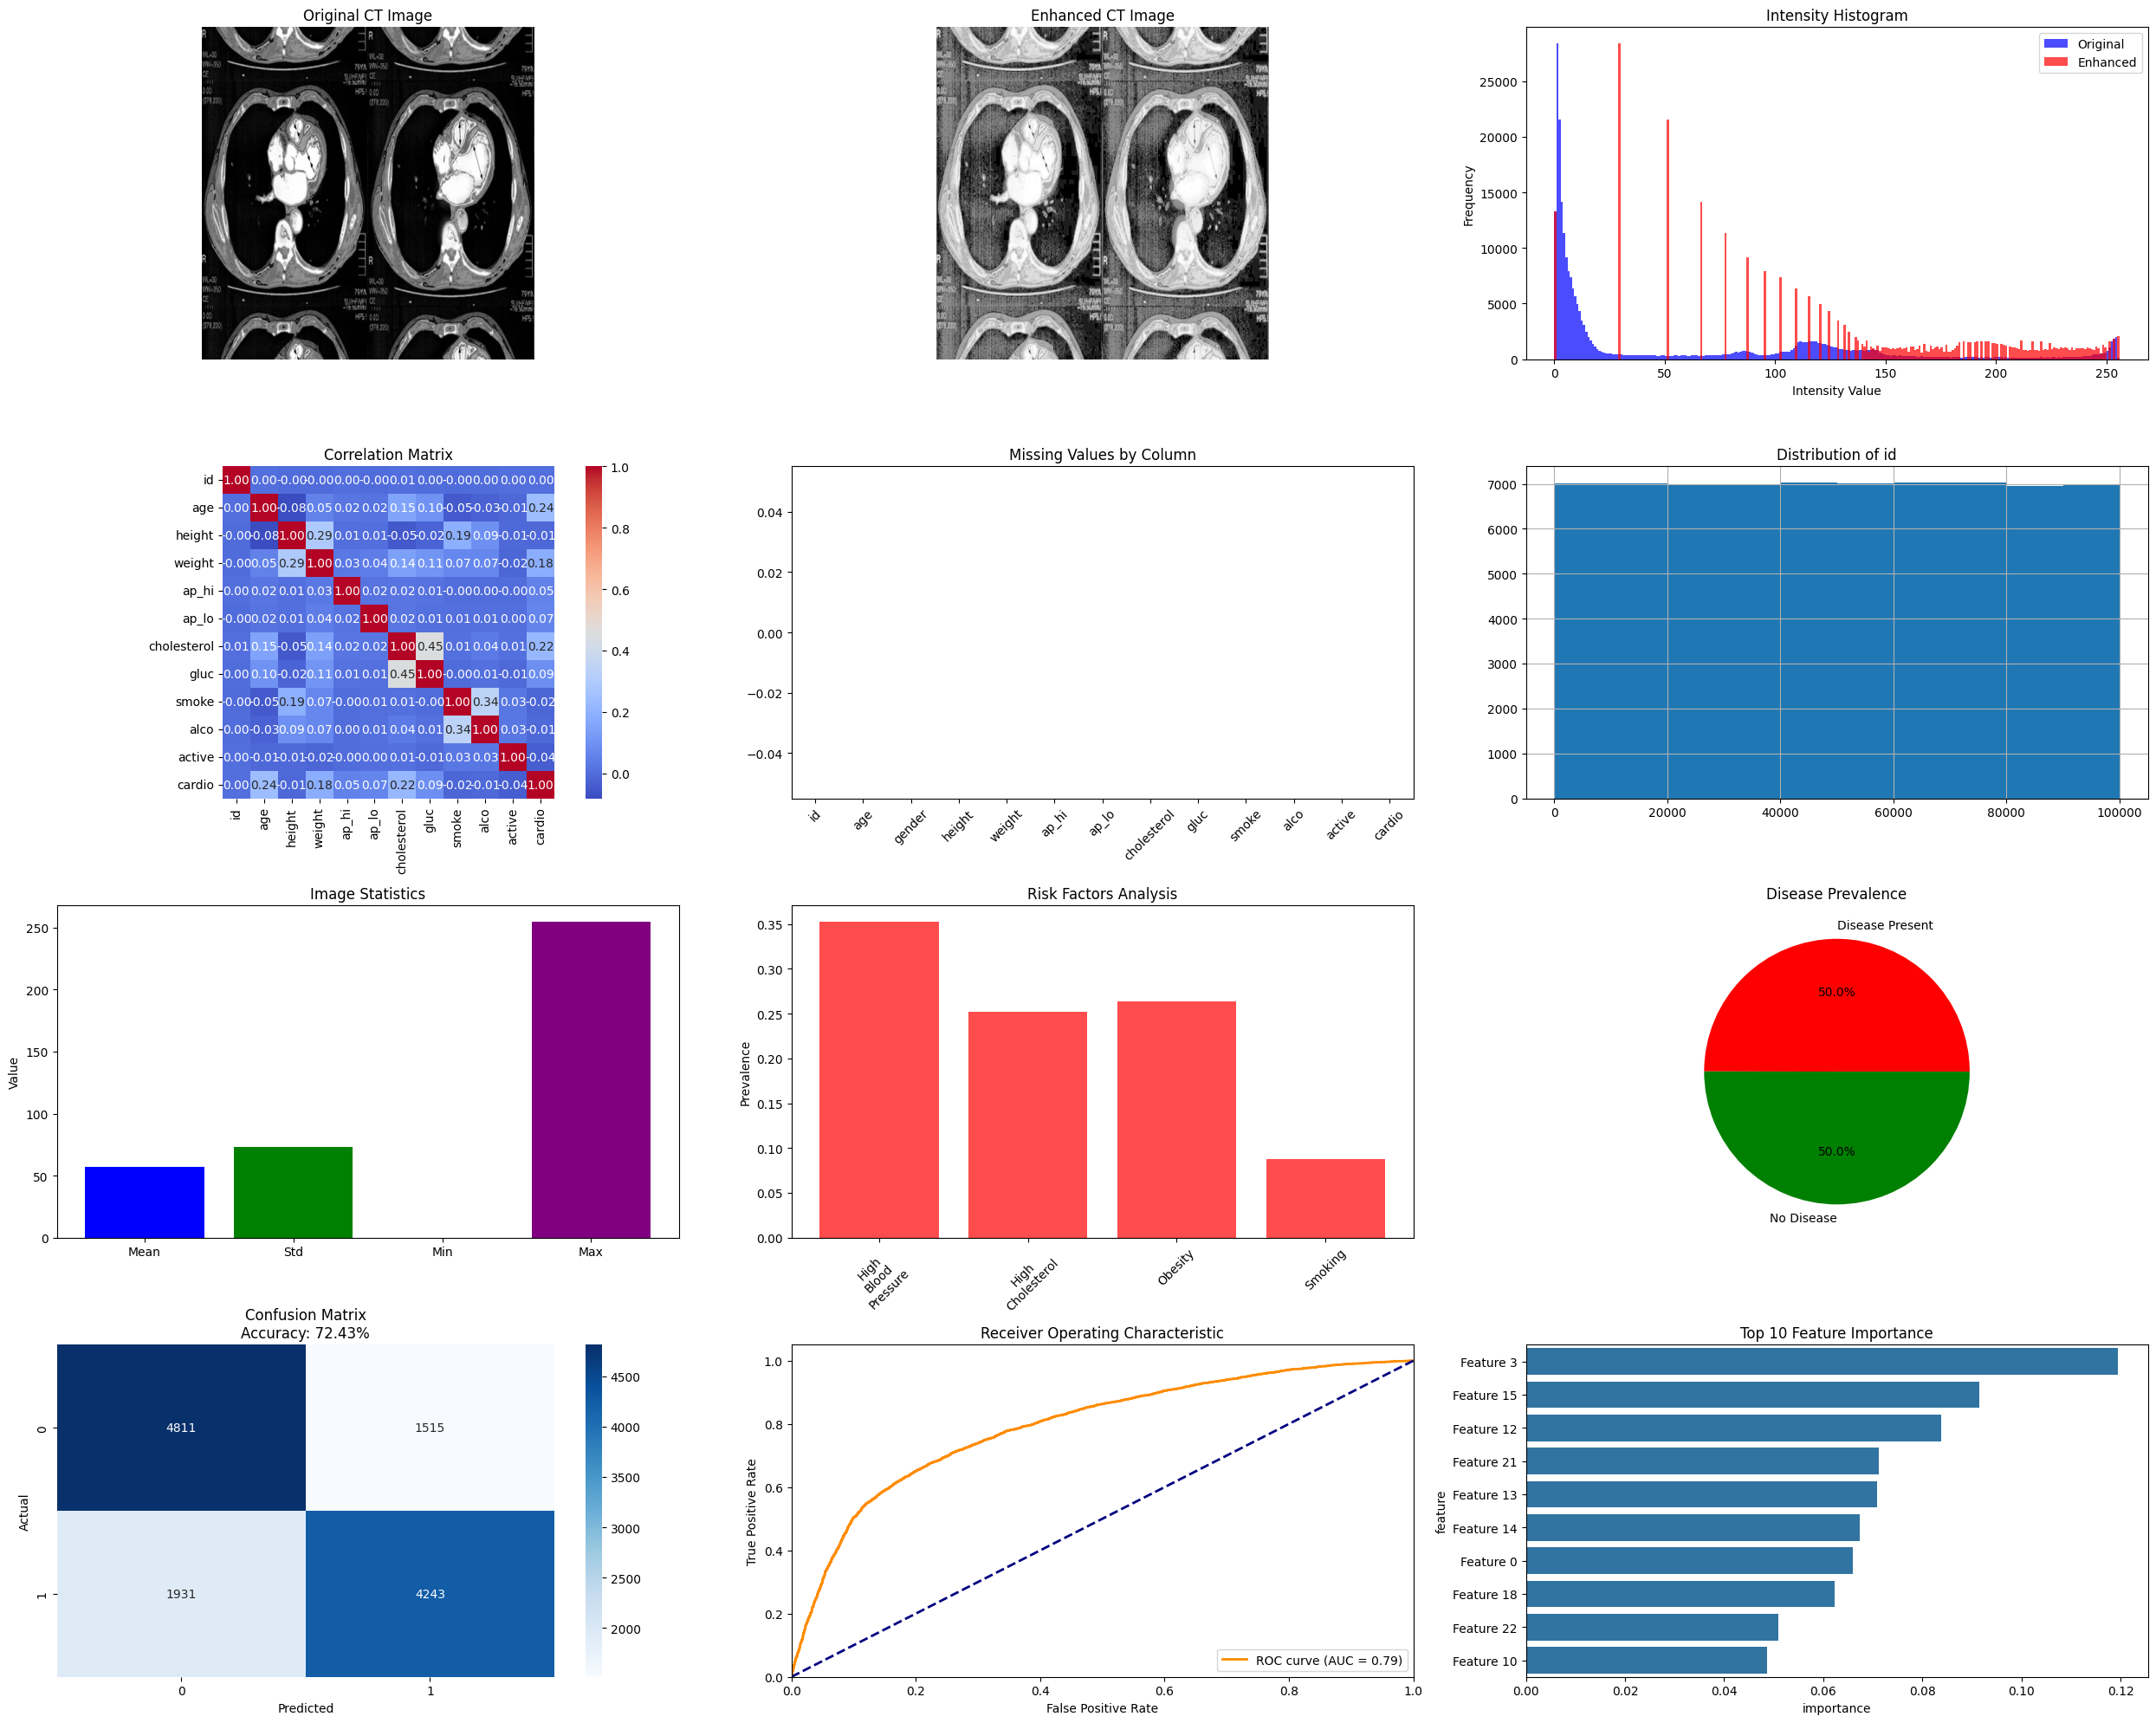


Image Analysis Results:
Image Shape: (512, 512)

Intensity Statistics:
Mean: 57.31
Std: 73.18
Min: 0.00
Max: 255.00

CSV Analysis Results:

Numerical Statistics:
                 id           age        height        weight         ap_hi  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean   49972.419900  19468.865814    164.359229     74.205690    128.817286   
std    28851.302323   2467.251667      8.210126     14.395757    154.011419   
min        0.000000  10798.000000     55.000000     10.000000   -150.000000   
25%    25006.750000  17664.000000    159.000000     65.000000    120.000000   
50%    50001.500000  19703.000000    165.000000     72.000000    120.000000   
75%    74889.250000  21327.000000    170.000000     82.000000    140.000000   
max    99999.000000  23713.000000    250.000000    200.000000  16020.000000   

              ap_lo   cholesterol          gluc         smoke          alco  \
count  70000.000000  70000.000000  70000.00000

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, Optional
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel

class CTDataAnalyzer:
    def __init__(self, img_height=512, img_width=512):
        self.img_height = img_height
        self.img_width = img_width
        self.model = RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            min_samples_split=8,
            min_samples_leaf=4,
            max_features='sqrt',
            bootstrap=True,
            random_state=42,
            class_weight='balanced',
            n_jobs=-1
        )
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.scaler = RobustScaler()
        self.smote = SMOTE(random_state=42)

    def validate_image(self, img: np.ndarray) -> bool:
        return img is not None and img.size > 0 and len(img.shape) >= 2

    def load_and_analyze_image(self, image_path: str) -> tuple:
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Image file not found: {image_path}")

        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if not self.validate_image(img):
            raise ValueError(f"Invalid or empty image loaded from {image_path}")

        img = cv2.resize(img, (self.img_width, self.img_height))
        img_enhanced = cv2.equalizeHist(img)

        analysis = {
            'intensity_stats': {
                'mean': float(np.mean(img)),
                'std': float(np.std(img)),
                'min': float(np.min(img)),
                'max': float(np.max(img))
            },
            'shape': img.shape,
            'histogram': np.histogram(img, bins=256, range=(0, 256))[0]
        }

        return img, img_enhanced, analysis

    def validate_csv(self, df: pd.DataFrame) -> bool:
        return df is not None and not df.empty and len(df.columns) > 0

    def analyze_csv_data(self, csv_path: str) -> Dict:
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"CSV file not found: {csv_path}")

        df = pd.read_csv(csv_path, sep=';')

        # Convert numeric columns
        numeric_columns = ['id', 'age', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
                         'gluc', 'smoke', 'alco', 'active', 'cardio']
        for col in numeric_columns:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        # Convert categorical columns
        if 'gender' in df.columns:
            df['gender'] = df['gender'].astype('category')

        if not self.validate_csv(df):
            raise ValueError(f"Invalid or empty CSV data loaded from {csv_path}")

        numerical_df = df.select_dtypes(include=[np.number])
        numerical_stats = numerical_df.describe() if not numerical_df.empty else pd.DataFrame()
        correlation_matrix = numerical_df.corr() if not numerical_df.empty else pd.DataFrame()
        missing_values = df.isnull().sum()
        data_types = df.dtypes

        return {
            'numerical_stats': numerical_stats,
            'correlation_matrix': correlation_matrix,
            'missing_values': missing_values,
            'data_types': data_types,
            'dataframe': df
        }

    def engineer_features(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        # Basic health metrics
        df['bmi'] = df['weight'] / ((df['height']/100) ** 2)
        df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
        df['mean_arterial_pressure'] = df['ap_lo'] + (df['pulse_pressure']/3)

        # Age-related features
        df['age_squared'] = df['age'] ** 2
        df['age_normalized'] = df['age'] / 365  # Convert to years if in days

        # BMI categories
        df['bmi_category'] = pd.cut(df['bmi'],
                                  bins=[0, 18.5, 25, 30, 100],
                                  labels=[0, 1, 2, 3])

        # Blood pressure categories
        df['bp_category'] = ((df['ap_hi'] >= 140).astype(int) +
                           (df['ap_lo'] >= 90).astype(int))

        # Interaction features
        df['bmi_age'] = df['bmi'] * df['age_normalized']
        df['bp_product'] = df['ap_hi'] * df['ap_lo']

        # Risk scores
        df['combined_risk'] = (df['cholesterol'] + df['gluc'] +
                             df['smoke'] + df['alco'] - df['active'])

        # Binary features
        df['is_overweight'] = (df['bmi'] > 25).astype(int)
        df['is_hypertensive'] = ((df['ap_hi'] >= 140) |
                                (df['ap_lo'] >= 90)).astype(int)
        df['has_high_cholesterol'] = (df['cholesterol'] > 1).astype(int)

        # Health score
        df['health_score'] = (df['is_overweight'] + df['is_hypertensive'] +
                            df['has_high_cholesterol'] + df['smoke'] +
                            df['alco'] - df['active'])

        return df

    def clean_data(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        # Remove physiologically impossible values
        df = df[
            (df['ap_hi'] >= 70) & (df['ap_hi'] <= 240) &
            (df['ap_lo'] >= 40) & (df['ap_lo'] <= 160) &
            (df['height'] >= 140) & (df['height'] <= 220) &
            (df['weight'] >= 40) & (df['weight'] <= 200) &
            (df['ap_hi'] > df['ap_lo'])
        ]

        # Remove outliers using IQR method
        def remove_outliers(df, column):
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            return df[(df[column] >= Q1 - 1.5*IQR) &
                     (df[column] <= Q3 + 1.5*IQR)]

        numerical_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
        for col in numerical_columns:
            df = remove_outliers(df, col)

        return df.dropna()

    def prepare_model_data(self, csv_analysis: Dict):
        df = csv_analysis['dataframe']

        # Clean and engineer features
        df = self.clean_data(df)
        df = self.engineer_features(df)

        # Select features for prediction
        features = [
            'age', 'height', 'weight', 'ap_hi', 'ap_lo',
            'cholesterol', 'gluc', 'smoke', 'alco', 'active',
            'bmi', 'pulse_pressure', 'mean_arterial_pressure',
            'age_squared', 'bmi_age', 'bp_product', 'combined_risk',
            'is_overweight', 'is_hypertensive', 'has_high_cholesterol',
            'health_score', 'age_normalized', 'bp_category'
        ]

        X = df[features]
        y = df['cardio']

        # Split with stratification
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        # Scale features
        self.X_train = self.scaler.fit_transform(self.X_train)
        self.X_test = self.scaler.transform(self.X_test)

        # Apply SMOTE for class balancing
        self.X_train, self.y_train = self.smote.fit_resample(self.X_train, self.y_train)

    def calculate_image_accuracy(self, img_original: np.ndarray, img_enhanced: np.ndarray) -> Dict:
        try:
            ssim_index = ssim(img_original, img_enhanced)
            mse = np.mean((img_original - img_enhanced) ** 2)
            psnr = 100 if mse == 0 else 20 * np.log10(255.0 / np.sqrt(mse))
            contrast_original = img_original.std()
            contrast_enhanced = img_enhanced.std()
            contrast_improvement = (contrast_enhanced - contrast_original) / contrast_original

            return {
                'ssim_score': ssim_index,
                'mse': mse,
                'psnr': psnr,
                'contrast_improvement': contrast_improvement
            }
        except Exception as e:
            raise ValueError(f"Error calculating image accuracy: {str(e)}")

    def predict_disease(self, csv_analysis: Dict) -> Dict:
        df = csv_analysis['dataframe']

        # Prepare data and train model
        self.prepare_model_data(csv_analysis)

        # Train model
        self.model.fit(self.X_train, self.y_train)

        # Make predictions
        y_pred = self.model.predict(self.X_test)
        y_pred_proba = self.model.predict_proba(self.X_test)

        # Calculate metrics
        acc_score = accuracy_score(self.y_test, y_pred)
        conf_matrix = confusion_matrix(self.y_test, y_pred)
        class_report = classification_report(self.y_test, y_pred)

        # Calculate risk factors
        risk_factors = {
            'high_blood_pressure': ((df['ap_hi'] >= 140) |
                                  (df['ap_lo'] >= 90)).mean(),
            'high_cholesterol': (df['cholesterol'] > 1).mean(),
            'obesity': (df['weight'] / ((df['height']/100) ** 2) >= 30).mean(),
            'smoking': (df['smoke'] == 1).mean()
        }

        disease_prevalence = (df['cardio'] == 1).mean()

        return {
            'risk_factors': risk_factors,
            'disease_prevalence': disease_prevalence,
            'model_accuracy': acc_score,
            'confusion_matrix': conf_matrix,
            'classification_report': class_report,
            'prediction_probabilities': y_pred_proba
        }

def visualize_combined_analysis(image_path: str, csv_path: str, output_dir: Optional[str] = None):
    analyzer = CTDataAnalyzer()

    try:
        img_original, img_enhanced, img_analysis = analyzer.load_and_analyze_image(image_path)
        csv_analysis = analyzer.analyze_csv_data(csv_path)
        disease_analysis = analyzer.predict_disease(csv_analysis)

        plt.figure(figsize=(25, 20))

        # Original plots (1-9) remain the same as in your original code...
        plt.subplot(4, 3, 1)
        plt.imshow(img_original, cmap='gray')
        plt.title('Original CT Image')
        plt.axis('off')

        plt.subplot(4, 3, 2)
        plt.imshow(img_enhanced, cmap='gray')
        plt.title('Enhanced CT Image')
        plt.axis('off')

        plt.subplot(4, 3, 3)
        plt.hist(img_original.ravel(), 256, [0, 256], color='blue', alpha=0.7, label='Original')
        plt.hist(img_enhanced.ravel(), 256, [0, 256], color='red', alpha=0.7, label='Enhanced')
        plt.title('Intensity Histogram')
        plt.xlabel('Intensity Value')
        plt.ylabel('Frequency')
        plt.legend()

        if not csv_analysis['correlation_matrix'].empty:
            plt.subplot(4, 3, 4)
            sns.heatmap(csv_analysis['correlation_matrix'], annot=True, cmap='coolwarm', fmt='.2f', square=True)
            plt.title('Correlation Matrix')

        plt.subplot(4, 3, 5)
        if not csv_analysis['missing_values'].empty:
            csv_analysis['missing_values'].plot(kind='bar')
            plt.title('Missing Values by Column')
            plt.xticks(rotation=45)

        plt.subplot(4, 3, 6)
        numerical_cols = csv_analysis['dataframe'].select_dtypes(include=[np.number]).columns
        if len(numerical_cols) > 0:
            csv_analysis['dataframe'][numerical_cols[0]].hist()
            plt.title(f'Distribution of {numerical_cols[0]}')

        plt.subplot(4, 3, 7)
        stats = img_analysis['intensity_stats']
        plt.bar(['Mean', 'Std', 'Min', 'Max'],
                [stats['mean'], stats['std'], stats['min'], stats['max']],
                color=['blue', 'green', 'red', 'purple'])
        plt.title('Image Statistics')
        plt.ylabel('Value')

        plt.subplot(4, 3, 8)
        factors = list(disease_analysis['risk_factors'].keys())
        values = list(disease_analysis['risk_factors'].values())
        plt.bar(range(len(factors)), values, color='red', alpha=0.7)
        plt.xticks(range(len(factors)), [f.replace('_', '\n').title() for f in factors], rotation=45)
        plt.title('Risk Factors Analysis')
        plt.ylabel('Prevalence')

        plt.subplot(4, 3, 9)
        plt.pie([disease_analysis['disease_prevalence'], 1-disease_analysis['disease_prevalence']],
                labels=['Disease Present', 'No Disease'], colors=['red', 'green'], autopct='%1.1f%%')
        plt.title('Disease Prevalence')

     # Continuing from the visualization function...

        # Add confusion matrix with accuracy score
        plt.subplot(4, 3, 10)
        sns.heatmap(disease_analysis['confusion_matrix'], annot=True, fmt='d', cmap='Blues')
        plt.title(f"Confusion Matrix\nAccuracy: {disease_analysis['model_accuracy']:.2%}")
        plt.xlabel('Predicted')
        plt.ylabel('Actual')

        # Add ROC curve if available
        plt.subplot(4, 3, 11)
        probabilities = disease_analysis['prediction_probabilities'][:, 1]
        from sklearn.metrics import roc_curve, auc
        fpr, tpr, _ = roc_curve(analyzer.y_test, probabilities)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color='darkorange', lw=2,
                label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic')
        plt.legend(loc="lower right")

        # Add feature importance plot
        plt.subplot(4, 3, 12)
        feature_importance = pd.DataFrame({
            'feature': [f'Feature {i}' for i in range(analyzer.X_train.shape[1])],
            'importance': analyzer.model.feature_importances_
        })
        feature_importance = feature_importance.sort_values('importance', ascending=False)[:10]
        sns.barplot(x='importance', y='feature', data=feature_importance)
        plt.title('Top 10 Feature Importance')

        plt.tight_layout()

        if output_dir:
            output_dir = Path(output_dir)
            output_dir.mkdir(exist_ok=True)
            output_path = output_dir / 'combined_analysis.png'
            plt.savefig(output_path)
            print(f"Analysis saved to {output_path}")

        plt.show()

        # Print detailed analysis results
        print("\nImage Analysis Results:")
        print(f"Image Shape: {img_analysis['shape']}")
        print("\nIntensity Statistics:")
        for key, value in img_analysis['intensity_stats'].items():
            print(f"{key.capitalize()}: {value:.2f}")

        print("\nCSV Analysis Results:")
        if not csv_analysis['numerical_stats'].empty:
            print("\nNumerical Statistics:")
            print(csv_analysis['numerical_stats'])
        print("\nMissing Values Summary:")
        print(csv_analysis['missing_values'])
        print("\nData Types:")
        print(csv_analysis['data_types'])

        print("\nDisease Analysis Results:")
        print(f"Overall Disease Prevalence: {disease_analysis['disease_prevalence']:.1%}")
        print("\nRisk Factors Prevalence:")
        for factor, value in disease_analysis['risk_factors'].items():
            print(f"{factor.replace('_', ' ').title()}: {value:.1%}")

        print("\nModel Performance:")
        print(f"Accuracy: {disease_analysis['model_accuracy']:.2%}")
        print("\nClassification Report:")
        print(disease_analysis['classification_report'])

    except Exception as e:
        print(f"Error during visualization: {str(e)}")
        raise


def main():
    try:
        output_dir = Path('output')
        output_dir.mkdir(exist_ok=True)

        image_path = '/content/CT Heart.jpg'
        csv_path = '/content/cardio_train.csv'
        visualize_combined_analysis(image_path, csv_path, str(output_dir))

    except FileNotFoundError as e:
        print(f"File not found: {str(e)}")
    except ValueError as e:
        print(f"Invalid data: {str(e)}")
    except Exception as e:
        print(f"Error in analysis: {str(e)}")


if __name__ == "__main__":
    main()

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, Optional, List, Tuple
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBClassifier

class CTDataAnalyzer:
    def __init__(self, img_height=512, img_width=512):
        self.img_height = img_height
        self.img_width = img_width
        self.models = {
            'rf': RandomForestClassifier(
                n_estimators=300,
                max_depth=20,
                min_samples_split=6,
                min_samples_leaf=3,
                max_features='sqrt',
                bootstrap=True,
                random_state=42,
                class_weight='balanced',
                n_jobs=-1
            ),
            'xgb': XGBClassifier(
                n_estimators=200,
                max_depth=8,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42
            ),
            'gb': GradientBoostingClassifier(
                n_estimators=200,
                max_depth=8,
                learning_rate=0.1,
                random_state=42
            )
        }
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.scaler = RobustScaler()
        self.smote = SMOTE(random_state=42)

        self.disease_thresholds = {
            'coronary_artery_disease': {
                'ap_hi': 140,
                'ap_lo': 90,
                'cholesterol': 2,
                'age': 50
            },
            'hypertensive_heart_disease': {
                'ap_hi': 160,
                'ap_lo': 100,
                'age': 45
            },
            'cardiomyopathy': {
                'ap_hi': 130,
                'ap_lo': 85,
                'bmi': 30
            }
        }

    def validate_image(self, img: np.ndarray) -> bool:
        return img is not None and img.size > 0 and len(img.shape) >= 2

    def load_and_analyze_image(self, image_path: str) -> tuple:
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Image file not found: {image_path}")

        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if not self.validate_image(img):
            raise ValueError(f"Invalid or empty image loaded from {image_path}")

        img = cv2.resize(img, (self.img_width, self.img_height))
        img_enhanced = cv2.equalizeHist(img)

        analysis = {
            'intensity_stats': {
                'mean': float(np.mean(img)),
                'std': float(np.std(img)),
                'min': float(np.min(img)),
                'max': float(np.max(img))
            },
            'shape': img.shape,
            'histogram': np.histogram(img, bins=256, range=(0, 256))[0]
        }

        return img, img_enhanced, analysis

    def analyze_image_features(self, img: np.ndarray) -> Dict:
        features = {}

        # Texture analysis
        gray_level = cv2.calcHist([img], [0], None, [256], [0, 256])
        features['texture_mean'] = np.mean(gray_level)
        features['texture_std'] = np.std(gray_level)

        # Edge detection
        edges = cv2.Canny(img, 100, 200)
        features['edge_density'] = np.sum(edges) / (img.shape[0] * img.shape[1])

        # Region properties
        ret, thresh = cv2.threshold(img, 127, 255, 0)
        contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            features['region_count'] = len(contours)
            areas = [cv2.contourArea(c) for c in contours]
            features['max_region_area'] = max(areas)
        else:
            features['region_count'] = 0
            features['max_region_area'] = 0

        return features

    def validate_csv(self, df: pd.DataFrame) -> bool:
        return df is not None and not df.empty and len(df.columns) > 0

    def analyze_csv_data(self, csv_path: str) -> Dict:
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"CSV file not found: {csv_path}")

        df = pd.read_csv(csv_path, sep=';')

        # Convert numeric columns
        numeric_columns = ['id', 'age', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
                         'gluc', 'smoke', 'alco', 'active', 'cardio']
        for col in numeric_columns:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        if 'gender' in df.columns:
            df['gender'] = df['gender'].astype('category')

        if not self.validate_csv(df):
            raise ValueError(f"Invalid or empty CSV data loaded from {csv_path}")

        numerical_df = df.select_dtypes(include=[np.number])
        numerical_stats = numerical_df.describe()
        correlation_matrix = numerical_df.corr()
        missing_values = df.isnull().sum()
        data_types = df.dtypes

        return {
            'numerical_stats': numerical_stats,
            'correlation_matrix': correlation_matrix,
            'missing_values': missing_values,
            'data_types': data_types,
            'dataframe': df
        }

    def detect_disease_type(self, patient_data: pd.Series, image_features: Dict) -> Dict:
        disease_probabilities = {}
        disease_indicators = {}

        for disease, thresholds in self.disease_thresholds.items():
            indicators = []
            for metric, threshold in thresholds.items():
                if metric in patient_data:
                    if metric == 'bmi':
                        value = patient_data['weight'] / ((patient_data['height']/100) ** 2)
                    else:
                        value = patient_data[metric]
                    indicators.append(value >= threshold)

            probability = sum(indicators) / len(indicators)
            disease_probabilities[disease] = probability
            disease_indicators[disease] = indicators

        # Adjust probabilities based on image features
        if image_features['edge_density'] > 0.5:
            disease_probabilities['coronary_artery_disease'] *= 1.2
        if image_features['texture_std'] > 50:
            disease_probabilities['cardiomyopathy'] *= 1.1

        return {
            'probabilities': disease_probabilities,
            'indicators': disease_indicators,
            'image_features': image_features
        }

    def engineer_features(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        # Health metrics
        df['bmi'] = df['weight'] / ((df['height']/100) ** 2)
        df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
        df['mean_arterial_pressure'] = df['ap_lo'] + (df['pulse_pressure']/3)

        # Age features
        df['age_squared'] = df['age'] ** 2
        df['age_normalized'] = df['age'] / 365

        # Categories
        df['bmi_category'] = pd.cut(df['bmi'],
                                  bins=[0, 18.5, 25, 30, 100],
                                  labels=[0, 1, 2, 3])

        df['bp_category'] = ((df['ap_hi'] >= 140).astype(int) +
                           (df['ap_lo'] >= 90).astype(int))

        # Interaction features
        df['bmi_age'] = df['bmi'] * df['age_normalized']
        df['bp_product'] = df['ap_hi'] * df['ap_lo']

        # Risk scores
        df['combined_risk'] = (df['cholesterol'] + df['gluc'] +
                             df['smoke'] + df['alco'] - df['active'])

        # Binary features
        df['is_overweight'] = (df['bmi'] > 25).astype(int)
        df['is_hypertensive'] = ((df['ap_hi'] >= 140) |
                                (df['ap_lo'] >= 90)).astype(int)
        df['has_high_cholesterol'] = (df['cholesterol'] > 1).astype(int)

        return df

    def clean_data(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        # Remove impossible values
        df = df[
            (df['ap_hi'] >= 70) & (df['ap_hi'] <= 240) &
            (df['ap_lo'] >= 40) & (df['ap_lo'] <= 160) &
            (df['height'] >= 140) & (df['height'] <= 220) &
            (df['weight'] >= 40) & (df['weight'] <= 200) &
            (df['ap_hi'] > df['ap_lo'])
        ]

        # Remove outliers
        def remove_outliers(df, column):
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            return df[(df[column] >= Q1 - 1.5*IQR) &
                     (df[column] <= Q3 + 1.5*IQR)]

        numerical_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
        for col in numerical_columns:
            df = remove_outliers(df, col)

        return df.dropna()

    def prepare_model_data(self, csv_analysis: Dict):
        df = csv_analysis['dataframe']

        # Clean and engineer features
        df = self.clean_data(df)
        df = self.engineer_features(df)

        features = [
            'age', 'height', 'weight', 'ap_hi', 'ap_lo',
            'cholesterol', 'gluc', 'smoke', 'alco', 'active',
            'bmi', 'pulse_pressure', 'mean_arterial_pressure',
            'age_squared', 'bmi_age', 'bp_product', 'combined_risk',
            'is_overweight', 'is_hypertensive', 'has_high_cholesterol'
        ]

        X = df[features]
        y = df['cardio']

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        self.X_train = self.scaler.fit_transform(self.X_train)
        self.X_test = self.scaler.transform(self.X_test)

        self.X_train, self.y_train = self.smote.fit_resample(self.X_train, self.y_train)

    def predict_disease(self, csv_analysis: Dict, img_original: np.ndarray) -> Dict:
        df = csv_analysis['dataframe']

        # Prepare data and train models
        self.prepare_model_data(csv_analysis)

        # Train and evaluate models
        predictions = {}
        probabilities = {}
        for name, model in self.models.items():
            model.fit(self.X_train, self.y_train)
            predictions[name] = model.predict(self.X_test)
            probabilities[name] = model.predict_proba(self.X_test)

        # Ensemble predictions
        weights = {'rf': 0.4, 'xgb': 0.35, 'gb': 0.25}
        weighted_proba = np.zeros_like(probabilities['rf'])
        for name, proba in probabilities.items():
            weighted_proba += weights[name] * proba

        final_predictions = (weighted_proba[:, 1] >= 0.5).astype(int)

        # Calculate metrics
        acc_score = accuracy_score(self.y_test, final_predictions)
        conf_matrix = confusion_matrix(self.y_test, final_predictions)
        class_report = classification_report(self.y_test, final_predictions)
        roc_auc = roc_auc_score(self.y_test, weighted_proba[:, 1])

        # Analyze specific cases
        detailed_analysis = []
        for idx, (true_label, pred_label) in enumerate(zip(self.y_test, final_predictions)):
            if true_label == 1 or pred_label == 1:
                patient_data = pd.Series(self.X_test[idx], index=features)
                image_features = self.analyze_image_features(img_original)
                disease_analysis = self.detect_disease_type(patient_data, image_features)
                detailed_analysis.append({
                    'true_label': true_label,
                    'predicted_label': pred_label,
                    'disease_analysis': disease_analysis
                })

        return {
            'model_accuracy': acc_score,
            'roc_auc_score': roc_auc,
            'confusion_matrix': conf_matrix,
            'classification_report': class_report,
            'prediction_probabilities': weighted_proba,
            'detailed_analysis': detailed_analysis
        }

def visualize_combined_analysis(image_path: str, csv_path: str, output_dir: Optional[str] = None):
    analyzer = CTDataAnalyzer()

    try:
        # Load and analyze data
        img_original, img_enhanced, img_analysis = analyzer.load_and_analyze_image(image_path)
        csv_analysis = analyzer.analyze_csv_data(csv_path)
        disease_analysis = analyzer.predict_disease(csv_analysis, img_original)

        # Create main visualization figure
        plt.figure(figsize=(25, 20))

        # 1. Image Analysis Section
        plt.subplot(4, 3, 1)
        plt.imshow(img_original, cmap='gray')
        plt.title('Original CT Image')
        plt.axis('off')

        plt.subplot(4, 3, 2)
        plt.imshow(img_enhanced, cmap='gray')
        plt.title('Enhanced CT Image')
        plt.axis('off')

        plt.subplot(4, 3, 3)
        plt.hist(img_original.ravel(), 256, [0, 256], color='blue', alpha=0.7, label='Original')
        plt.hist(img_enhanced.ravel(), 256, [0, 256], color='red', alpha=0.7, label='Enhanced')
        plt.title('Intensity Histogram')
        plt.xlabel('Intensity Value')
        plt.ylabel('Frequency')
        plt.legend()

        # 2. Statistical Analysis Section
        plt.subplot(4, 3, 4)
        if not csv_analysis['correlation_matrix'].empty:
            sns.heatmap(csv_analysis['correlation_matrix'],
                       annot=True, cmap='coolwarm', fmt='.2f', square=True)
            plt.title('Feature Correlation Matrix')

        plt.subplot(4, 3, 5)
        stats = img_analysis['intensity_stats']
        plt.bar(['Mean', 'Std', 'Min', 'Max'],
                [stats['mean'], stats['std'], stats['min'], stats['max']],
                color=['blue', 'green', 'red', 'purple'])
        plt.title('Image Statistics')
        plt.ylabel('Value')

        plt.subplot(4, 3, 6)
        disease_types = list(analyzer.disease_thresholds.keys())
        detected_diseases = []
        disease_scores = []

        for analysis in disease_analysis['detailed_analysis']:
            probs = analysis['disease_analysis']['probabilities']
            for disease in disease_types:
                if disease in probs and probs[disease] > 0.5:
                    detected_diseases.append(disease)
                    disease_scores.append(probs[disease])

        if detected_diseases:
            plt.bar(detected_diseases, disease_scores, color='red', alpha=0.7)
            plt.title('Detected Disease Types')
            plt.xticks(rotation=45)
            plt.ylabel('Confidence Score')

        # 3. Model Performance Section
        plt.subplot(4, 3, 7)
        sns.heatmap(disease_analysis['confusion_matrix'],
                   annot=True, fmt='d', cmap='Blues')
        plt.title(f"Confusion Matrix\nAccuracy: {disease_analysis['model_accuracy']:.2%}")
        plt.xlabel('Predicted')
        plt.ylabel('Actual')

        plt.subplot(4, 3, 8)
        # ROC curve
        fpr, tpr, _ = roc_curve(analyzer.y_test,
                               disease_analysis['prediction_probabilities'][:, 1])
        plt.plot(fpr, tpr, color='darkorange', lw=2,
                label=f'ROC (AUC = {disease_analysis["roc_auc_score"]:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")

        plt.subplot(4, 3, 9)
        # Feature importance from Random Forest model
        feature_importance = pd.DataFrame({
            'feature': analyzer.X_train.columns,
            'importance': analyzer.models['rf'].feature_importances_
        }).sort_values('importance', ascending=False)[:10]

        sns.barplot(x='importance', y='feature', data=feature_importance)
        plt.title('Top 10 Important Features')

        # 4. Disease Analysis Section
        plt.subplot(4, 3, 10)
        disease_distribution = pd.Series([
            analysis['disease_analysis']['probabilities']
            for analysis in disease_analysis['detailed_analysis']
        ]).value_counts()
        plt.pie(disease_distribution, labels=disease_distribution.index,
               autopct='%1.1f%%', colors=sns.color_palette("Set3"))
        plt.title('Disease Type Distribution')

        plt.subplot(4, 3, 11)
        risk_factors = {
            'High BP': (csv_analysis['dataframe']['ap_hi'] >= 140).mean(),
            'High Cholesterol': (csv_analysis['dataframe']['cholesterol'] > 1).mean(),
            'Smoking': (csv_analysis['dataframe']['smoke'] == 1).mean(),
            'Physical Inactivity': (csv_analysis['dataframe']['active'] == 0).mean()
        }
        plt.bar(risk_factors.keys(), risk_factors.values(), color='lightcoral')
        plt.title('Risk Factor Analysis')
        plt.xticks(rotation=45)
        plt.ylabel('Prevalence')

        plt.subplot(4, 3, 12)
        image_features = analyzer.analyze_image_features(img_original)
        plt.bar(image_features.keys(), image_features.values())
        plt.title('Image Feature Analysis')
        plt.xticks(rotation=45)
        plt.ylabel('Value')

        plt.tight_layout()

        # Save visualization if output directory is provided
        if output_dir:
            output_dir = Path(output_dir)
            output_dir.mkdir(exist_ok=True)
            output_path = output_dir / 'complete_analysis.png'
            plt.savefig(output_path)
            plt.close()

            # Save detailed report
            report_path = output_dir / 'analysis_report.txt'
            with open(report_path, 'w') as f:
                f.write("Heart Disease Analysis Report\n")
                f.write("=" * 50 + "\n\n")

                f.write("1. Model Performance\n")
                f.write(f"Accuracy: {disease_analysis['model_accuracy']:.2%}\n")
                f.write(f"ROC AUC Score: {disease_analysis['roc_auc_score']:.2f}\n\n")

                f.write("2. Classification Report\n")
                f.write(str(disease_analysis['classification_report']) + "\n\n")

                f.write("3. Detected Diseases\n")
                for analysis in disease_analysis['detailed_analysis']:
                    f.write("\nCase Analysis:\n")
                    f.write(f"True Label: {analysis['true_label']}\n")
                    f.write(f"Predicted Label: {analysis['predicted_label']}\n")
                    f.write("Disease Probabilities:\n")
                    for disease, prob in analysis['disease_analysis']['probabilities'].items():
                        f.write(f"- {disease}: {prob:.2%}\n")

            print(f"Analysis saved to {output_dir}")

    except Exception as e:
        print(f"Error during visualization: {str(e)}")
        raise

def main():
    try:
        # Set up paths
        image_path = '/content/CT Heart.jpg'
        csv_path = '/content/cardio_train.csv'
        output_dir = Path('output')
        output_dir.mkdir(exist_ok=True)

        # Run analysis
        visualize_combined_analysis(image_path, csv_path, str(output_dir))

    except FileNotFoundError as e:
        print(f"File not found: {str(e)}")
    except ValueError as e:
        print(f"Invalid data: {str(e)}")
    except Exception as e:
        print(f"Error in analysis: {str(e)}")

if __name__ == "__main__":
    main()

Error during visualization: name 'features' is not defined
Error in analysis: name 'features' is not defined


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, Optional
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from imblearn.over_sampling import SMOTE
import xgboost as xgb

class CTDataAnalyzer:
    def __init__(self, img_height=512, img_width=512):
        self.img_height = img_height
        self.img_width = img_width
        self.model = xgb.XGBClassifier(
            n_estimators=1000,
            learning_rate=0.1,
            max_depth=7,
            min_child_weight=1,
            gamma=0,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='binary:logistic',
            scale_pos_weight=1,
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss'
        )
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.scaler = RobustScaler()
        self.smote = SMOTE(random_state=42)

    def validate_image(self, img: np.ndarray) -> bool:
        return img is not None and img.size > 0 and len(img.shape) >= 2

    def load_and_analyze_image(self, image_path: str) -> tuple:
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Image file not found: {image_path}")

        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if not self.validate_image(img):
            raise ValueError(f"Invalid or empty image loaded from {image_path}")

        img = cv2.resize(img, (self.img_width, self.img_height))
        img_enhanced = cv2.equalizeHist(img)

        analysis = {
            'intensity_stats': {
                'mean': float(np.mean(img)),
                'std': float(np.std(img)),
                'min': float(np.min(img)),
                'max': float(np.max(img))
            },
            'shape': img.shape,
            'histogram': np.histogram(img, bins=256, range=(0, 256))[0]
        }

        return img, img_enhanced, analysis

    def validate_csv(self, df: pd.DataFrame) -> bool:
        return df is not None and not df.empty and len(df.columns) > 0

    def analyze_csv_data(self, csv_path: str) -> Dict:
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"CSV file not found: {csv_path}")

        df = pd.read_csv(csv_path, sep=';')

        numeric_columns = ['id', 'age', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
                         'gluc', 'smoke', 'alco', 'active', 'cardio']
        for col in numeric_columns:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        if 'gender' in df.columns:
            df['gender'] = df['gender'].astype('category')

        if not self.validate_csv(df):
            raise ValueError(f"Invalid or empty CSV data loaded from {csv_path}")

        numerical_df = df.select_dtypes(include=[np.number])
        numerical_stats = numerical_df.describe() if not numerical_df.empty else pd.DataFrame()
        correlation_matrix = numerical_df.corr() if not numerical_df.empty else pd.DataFrame()
        missing_values = df.isnull().sum()
        data_types = df.dtypes

        return {
            'numerical_stats': numerical_stats,
            'correlation_matrix': correlation_matrix,
            'missing_values': missing_values,
            'data_types': data_types,
            'dataframe': df
        }

    def engineer_features(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        df['bmi'] = df['weight'] / ((df['height']/100) ** 2)
        df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
        df['mean_arterial_pressure'] = df['ap_lo'] + (df['pulse_pressure']/3)
        df['age_squared'] = df['age'] ** 2
        df['age_normalized'] = df['age'] / 365
        df['bmi_category'] = pd.cut(df['bmi'],
                                  bins=[0, 18.5, 25, 30, 100],
                                  labels=[0, 1, 2, 3])
        df['bp_category'] = ((df['ap_hi'] >= 140).astype(int) +
                           (df['ap_lo'] >= 90).astype(int))
        df['bmi_age'] = df['bmi'] * df['age_normalized']
        df['bp_product'] = df['ap_hi'] * df['ap_lo']
        df['combined_risk'] = (df['cholesterol'] + df['gluc'] +
                             df['smoke'] + df['alco'] - df['active'])
        df['is_overweight'] = (df['bmi'] > 25).astype(int)
        df['is_hypertensive'] = ((df['ap_hi'] >= 140) |
                                (df['ap_lo'] >= 90)).astype(int)
        df['has_high_cholesterol'] = (df['cholesterol'] > 1).astype(int)
        df['health_score'] = (df['is_overweight'] + df['is_hypertensive'] +
                            df['has_high_cholesterol'] + df['smoke'] +
                            df['alco'] - df['active'])

        return df

    def clean_data(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        df = df[
            (df['ap_hi'] >= 70) & (df['ap_hi'] <= 240) &
            (df['ap_lo'] >= 40) & (df['ap_lo'] <= 160) &
            (df['height'] >= 140) & (df['height'] <= 220) &
            (df['weight'] >= 40) & (df['weight'] <= 200) &
            (df['ap_hi'] > df['ap_lo'])
        ]

        def remove_outliers(df, column):
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            return df[(df[column] >= Q1 - 1.5*IQR) &
                     (df[column] <= Q3 + 1.5*IQR)]

        numerical_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
        for col in numerical_columns:
            df = remove_outliers(df, col)

        return df.dropna()

    def prepare_model_data(self, csv_analysis: Dict):
        df = csv_analysis['dataframe']

        df = self.clean_data(df)
        df = self.engineer_features(df)

        features = [
            'age', 'height', 'weight', 'ap_hi', 'ap_lo',
            'cholesterol', 'gluc', 'smoke', 'alco', 'active',
            'bmi', 'pulse_pressure', 'mean_arterial_pressure',
            'age_squared', 'bmi_age', 'bp_product', 'combined_risk',
            'is_overweight', 'is_hypertensive', 'has_high_cholesterol',
            'health_score', 'age_normalized', 'bp_category'
        ]

        X = df[features]
        y = df['cardio']

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        self.X_train = self.scaler.fit_transform(self.X_train)
        self.X_test = self.scaler.transform(self.X_test)

        self.X_train, self.y_train = self.smote.fit_resample(self.X_train, self.y_train)

    def calculate_image_accuracy(self, img_original: np.ndarray, img_enhanced: np.ndarray) -> Dict:
        try:
            ssim_index = ssim(img_original, img_enhanced)
            mse = np.mean((img_original - img_enhanced) ** 2)
            psnr = 100 if mse == 0 else 20 * np.log10(255.0 / np.sqrt(mse))
            contrast_original = img_original.std()
            contrast_enhanced = img_enhanced.std()
            contrast_improvement = (contrast_enhanced - contrast_original) / contrast_original

            return {
                'ssim_score': ssim_index,
                'mse': mse,
                'psnr': psnr,
                'contrast_improvement': contrast_improvement
            }
        except Exception as e:
            raise ValueError(f"Error calculating image accuracy: {str(e)}")

    def predict_disease(self, csv_analysis: Dict) -> Dict:
        df = csv_analysis['dataframe']

        self.prepare_model_data(csv_analysis)

        eval_set = [(self.X_train, self.y_train), (self.X_test, self.y_test)]
        self.model.fit(self.X_train, self.y_train,
                      eval_set=eval_set,
                      verbose=False)

        y_pred = self.model.predict(self.X_test)
        y_pred_proba = self.model.predict_proba(self.X_test)

        acc_score = accuracy_score(self.y_test, y_pred)
        conf_matrix = confusion_matrix(self.y_test, y_pred)
        class_report = classification_report(self.y_test, y_pred)

        risk_factors = {
            'high_blood_pressure': ((df['ap_hi'] >= 140) |
                                  (df['ap_lo'] >= 90)).mean(),
            'high_cholesterol': (df['cholesterol'] > 1).mean(),
            'obesity': (df['weight'] / ((df['height']/100) ** 2) >= 30).mean(),
            'smoking': (df['smoke'] == 1).mean()
        }

        disease_prevalence = (df['cardio'] == 1).mean()

        return {
            'risk_factors': risk_factors,
            'disease_prevalence': disease_prevalence,
            'model_accuracy': acc_score,
            'confusion_matrix': conf_matrix,
            'classification_report': class_report,
            'prediction_probabilities': y_pred_proba
        }